# Valutazione file iniziale

## IMPORT

In [1]:
from dl_client import DatalakeClient
import pandas as pd

client = DatalakeClient()

## Ricerca file

In [44]:
search = client.query_files(query={'custom.level': 'raw', 'custom.file_code': ['EUROIMMUN']})
files = [x['filename'] for x in search['included_files']]
print(len(files))# Print the number of files found

1


In [45]:
print(files)

['ADNI_EUROIMMUN_11Aug2025.csv']


## Download zip file trovati

In [46]:
zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)



## Apertura singoli file

In [47]:
file_name = list(zip_files.keys())[0]
print(file_name)
dataset = zip_files[file_name]

df_new = dataset.copy(deep=True)
df_new.head()

ADNI_EUROIMMUN_11Aug2025.csv


,RID,VISCODE,VISCODE2,EXAMDATE,POOL,DRAWTIME,COMMENTS,BETA_AMYLOID_1_40,BETA_AMYLOID_1_42,BETA_AMYLOID_42_40,update_stamp
0,51,v06,m72,2011-08-11,NaN,13:00:00,NaN,7324.79,264.01,0.036043,2023-08-10 07:56:38.0
1,59,m60,m60,2010-12-15,NaN,09:00:00,NaN,8431.15,1184.28,0.140465,2023-08-10 07:56:38.0
2,232,m60,m60,2011-04-05,NaN,13:00:00,NaN,8454.41,772.85,0.091414,2023-08-10 07:56:38.0
3,259,m60,m60,2011-04-14,NaN,14:00:00,NaN,9887.33,580.35,0.058696,2023-08-10 07:56:38.0
4,272,v06,m72,2012-06-06,NaN,11:00:00,NaN,9835.15,918.71,0.093411,2023-08-10 07:56:38.0


In [27]:
df_new.keys()

Index(['RID', 'PTID', 'SUBJID', 'PHASE', 'VISCODE', 'VISCODE2', 'DRAWDATE',
       'PHC_Visit', 'PHC_Age_Biomarker', 'PHC_Age_Cognition', 'PHC_Diagnosis',
       'PHC_Sex', 'PHC_Race', 'PHC_Ethnicity', 'PHC_Education', 'AB42_RAW',
       'PHC_AB42', 'Tau_RAW', 'PHC_Tau', 'pTau_RAW', 'PHC_pTau', 'AT_class',
       'Platform', 'PHC_SCeNS_AB42_Score', 'PHC_SCeNS_pTau_Score',
       'update_stamp'],
      dtype='object')

## conto soggetti e soggetti con 2+ visits

In [48]:
tot_sub = len(df_new['RID'].unique())
print('totale subject:', tot_sub)
multiple_visists = (df_new['RID'].value_counts() > 1).sum()
print('subjects with multiple visits: ', multiple_visists)

totale subject: 121
subjects with multiple visits:  121


## range alcune variabili

In [49]:
var_interesse = ['BETA_AMYLOID_1_40', 'BETA_AMYLOID_1_42', 'BETA_AMYLOID_42_40']
df_interesse= df_new[var_interesse]
df_interesse.head()

,BETA_AMYLOID_1_40,BETA_AMYLOID_1_42,BETA_AMYLOID_42_40
0,7324.79,264.01,0.036043
1,8431.15,1184.28,0.140465
2,8454.41,772.85,0.091414
3,9887.33,580.35,0.058696
4,9835.15,918.71,0.093411


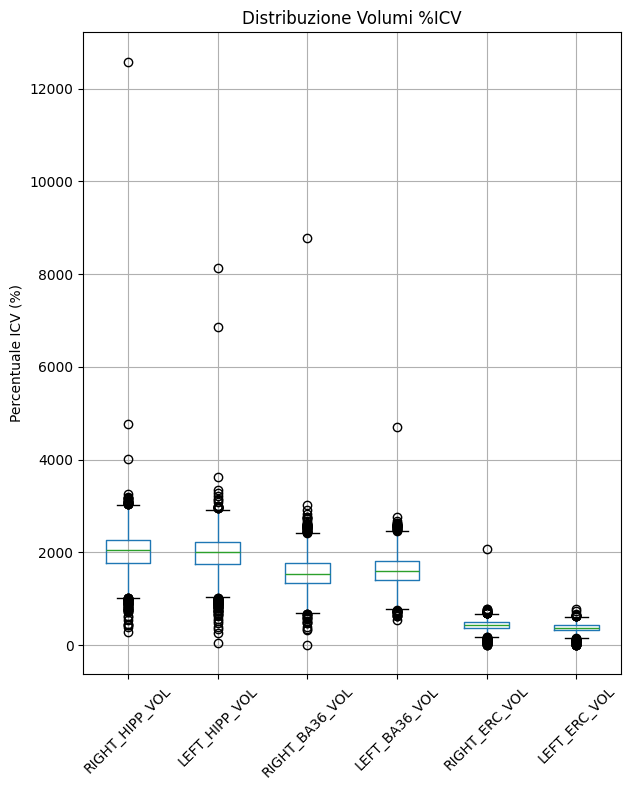

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione del plot
plt.figure(figsize=(12, 8))

# Box plot per le percentuali ICV



plt.subplot(1, 2, 2)
df_interesse.boxplot(rot=45)
plt.title('Distribuzione Volumi %ICV')
plt.ylabel('Percentuale ICV (%)')

plt.tight_layout()
plt.show()

In [ ]:
# Calcolo del 1° e 99° percentile per ciascun volume ICV
print("=== 1° E 99° PERCENTILE PER VARIABILI %ICV ===")
print()

percentiles = [1, 99]

# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=var_interesse, columns=['1° percentile', '99° percentile'])
for var in  var_interesse:
    percentile_df.loc[var, '1° percentile'] = df_interesse[var].quantile(0.01)
    percentile_df.loc[var, '99° percentile'] = df_interesse[var].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== 1° E 99° PERCENTILE PER VARIABILI %ICV ===

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
RIGHT_HIPP_VOL,965.82553,2927.34084
LEFT_HIPP_VOL,912.3652,2828.11126
RIGHT_BA36_VOL,813.95005,2439.15625
LEFT_BA36_VOL,851.2936,2411.67038
RIGHT_ERC_VOL,170.11728,656.35116
LEFT_ERC_VOL,143.3302,571.53336
ICV,1137452.72284,1810874.34698


# MERGE 2 file per corrispondenza soggetti-examdate

In [2]:
file_code = 'UPENNBIOMK_ROCHE_ELECSYS'
search = client.query_files(
    query={
        'custom.level' : 'cleaned_01',
        'custom.file_code': file_code
    }
)

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)

file_name = list(zip_files.keys())[0]
dataset = zip_files[file_name]

df_B = dataset.copy(deep=True)

In [5]:
# Crea la nuova colonna AT_profile basata su Apositive e Tpositive
def get_AT_profile(row):
    A = 'A+' if row['Apositive'] == 1 else 'A-'
    T = 'T+' if row['Tpositive'] == 1 else 'T-'
    return f"{A}{T}"

df_B['AT_profile'] = df_B.apply(get_AT_profile, axis=1)

In [3]:
file_code = 'ADSP_PHC_BIOMARKER'
search = client.query_files(
    query={
        'custom.level' : 'raw',
        'custom.file_code': file_code
    }
)

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)

file_name = list(zip_files.keys())[0]
dataset = zip_files[file_name]

df_A = dataset.copy(deep=True)


In [6]:
if 'DRAWDATE' in df_A.columns:
    df_A = df_A.rename(columns={'DRAWDATE': 'EXAMDATE'})

df_A['TauAB42_RAW'] = df_A['Tau_RAW']/df_A['AB42_RAW']
df_A['pTauAB42_RAW'] = df_A['pTau_RAW']/df_A['AB42_RAW']


In [7]:
# Trova le righe in df_A e df_B che hanno medesimo RID e EXAMDATE

# Assicuriamoci che le colonne abbiano lo stesso nome e tipo
df_A_matched = df_A.copy()
df_B_matched = df_B.copy()
if 'EXAMDARE' in df_A_matched.columns:
    df_A_matched = df_A_matched.rename(columns={'EXAMDARE': 'EXAMDATE'})
if 'EXAMDARE' in df_B_matched.columns:
    df_B_matched = df_B_matched.rename(columns={'EXAMDARE': 'EXAMDATE'})

# Eseguiamo un inner merge per trovare le righe comuni per RID ed EXAMDATE
common_rows = pd.merge(
    df_A_matched,
    df_B_matched,
    on=['RID', 'EXAMDATE'],
    suffixes=('_A', '_B')
)

common_rows


,RID,PTID,SUBJID,PHASE,VISCODE,VISCODE2_A,EXAMDATE,PHC_Visit,PHC_Age_Biomarker,PHC_Age_Cognition,...,AB42,TTAU,PTAU,AB4240,TTAU_AB42,PTAU_AB42,Apositive,Tpositive,Npositive,AT_profile
0,3,011_S_0003,G-ADNI-AN000439,ADNI1,m12,m12,2006-09-13,3.0,82.37,82.365503,...,601.4,251.70,24.18,NaN,0.418523,0.040206,1.0,1.0,1.0,A+T+
1,4,022_S_0004,G-ADNI-AN000446,ADNI1,m12,m12,2006-11-28,3.0,68.91,68.867899,...,1176.0,159.70,13.30,NaN,0.135799,0.011310,0.0,0.0,0.0,A-T-
2,5,011_S_0005,G-ADNI-AN000663,ADNI1,m12,m12,2006-09-06,3.0,74.77,74.762491,...,472.8,334.10,34.04,NaN,0.706641,0.071997,1.0,1.0,1.0,A+T+
3,8,011_S_0008,ADNI_011_S_0008,ADNI1,m12,m12,2006-09-20,3.0,85.56,85.552361,...,2589.0,397.70,34.28,NaN,0.153611,0.013241,0.0,0.0,0.0,A-T-
4,10,011_S_0010,G-ADNI-AN000438,ADNI1,m12,m12,2006-11-10,3.0,74.94,74.940452,...,340.0,287.70,27.37,NaN,0.846176,0.080500,1.0,1.0,1.0,A+T+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1233,5289,032_S_5289,G-ADNI-AN000304,ADNI2,v03,bl,2013-11-18,1.0,60.05,60.027379,...,1665.0,187.10,15.79,NaN,0.112372,0.009483,0.0,0.0,0.0,A-T-
1234,5290,024_S_5290,G-ADNI-AN000343,ADNI2,v03,bl,2013-09-27,1.0,67.16,67.148528,...,899.4,501.30,53.30,NaN,0.557372,0.059262,1.0,1.0,1.0,A+T+
1235,5292,057_S_5292,G-ADNI-AN000355,ADNI2,v03,bl,2013-11-13,1.0,74.54,74.535250,...,928.3,375.70,36.39,NaN,0.404718,0.039201,1.0,1.0,1.0,A+T+
1236,5295,057_S_5295,G-ADNI-AN000309,ADNI2,v03,bl,2013-12-17,1.0,75.63,75.613963,...,416.8,88.69,8.53,NaN,0.212788,0.020465,1.0,0.0,0.0,A+T-


In [8]:
common_rows.keys()

Index(['RID', 'PTID', 'SUBJID', 'PHASE', 'VISCODE', 'VISCODE2_A', 'EXAMDATE',
       'PHC_Visit', 'PHC_Age_Biomarker', 'PHC_Age_Cognition', 'PHC_Diagnosis',
       'PHC_Sex', 'PHC_Race', 'PHC_Ethnicity', 'PHC_Education', 'AB42_RAW',
       'PHC_AB42', 'Tau_RAW', 'PHC_Tau', 'pTau_RAW', 'PHC_pTau', 'AT_class',
       'Platform', 'PHC_SCeNS_AB42_Score', 'PHC_SCeNS_pTau_Score',
       'update_stamp', 'TauAB42_RAW', 'pTauAB42_RAW', 'COHORT', 'VISCODE2_B',
       'VISIT_MONTH', 'RUNDATE', 'AB40', 'AB42', 'TTAU', 'PTAU', 'AB4240',
       'TTAU_AB42', 'PTAU_AB42', 'Apositive', 'Tpositive', 'Npositive',
       'AT_profile'],
      dtype='object')

In [9]:
df_focus= common_rows[['RID', 'EXAMDATE', 'AB42_RAW', 'AB42', 'Tau_RAW', 'TTAU', 'pTau_RAW', 'PTAU', 'TauAB42_RAW', 'TTAU_AB42', 'pTauAB42_RAW', 'PTAU_AB42', 'AT_class', 'AT_profile']]

In [10]:
df_focus

,RID,EXAMDATE,AB42_RAW,AB42,Tau_RAW,TTAU,pTau_RAW,PTAU,TauAB42_RAW,TTAU_AB42,pTauAB42_RAW,PTAU_AB42,AT_class,AT_profile
0,3,2006-09-13,137.0,601.4,76.5,251.70,21.1,24.18,0.558394,0.418523,0.154015,0.040206,A+T-,A+T+
1,4,2006-11-28,246.0,1176.0,49.4,159.70,13.5,13.30,0.200813,0.135799,0.054878,0.011310,A-T-,A-T-
2,5,2006-09-06,136.0,472.8,120.0,334.10,40.5,34.04,0.882353,0.706641,0.297794,0.071997,A+T+,A+T+
3,8,2006-09-20,228.0,2589.0,94.6,397.70,39.6,34.28,0.414912,0.153611,0.173684,0.013241,A-T+,A-T-
4,10,2006-11-10,92.8,340.0,82.6,287.70,24.5,27.37,0.890086,0.846176,0.264009,0.080500,A+T-,A+T+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1233,5289,2013-11-18,232.0,1665.0,41.9,187.10,51.3,15.79,0.180603,0.112372,0.221121,0.009483,A-T+,A-T-
1234,5290,2013-09-27,128.0,899.4,148.0,501.30,79.7,53.30,1.156250,0.557372,0.622656,0.059262,A+T+,A+T+
1235,5292,2013-11-13,154.0,928.3,110.0,375.70,100.0,36.39,0.714286,0.404718,0.649351,0.039201,A+T+,A+T+
1236,5295,2013-12-17,117.0,416.8,20.5,88.69,12.4,8.53,0.175214,0.212788,0.105983,0.020465,A+T-,A+T-


In [73]:
# Trova le righe dove AT_class e AT_profile non corrispondono
non_corrispondenti = df_focus[df_focus['AT_class'] != df_focus['AT_profile']]

# Conta quante righe non corrispondono tra le due colonne
numero_non_corrispondenti = non_corrispondenti.shape[0]

print(f"Numero di righe dove AT_class e AT_profile non corrispondono: {numero_non_corrispondenti}")


Numero di righe dove AT_class e AT_profile non corrispondono: 404


## Valutazion corrispondenza di un parametro misurato in maniera differente
### Analisi consigliate (ordine pratico)

#### A. Scatter + linea identità

* Traccia y (metodo 2) vs x (metodo 1) con la linea y=x.

* Se i punti stanno sulla y=x → buon accordo visivo.

#### B. Regressione per metodi di misura

* Deming (errore in entrambi): stima slope e intercept con IC95%.

    * Intercambiabilità buona se slope ≈ 1 e intercept ≈ 0 (e IC95% includono 1 e 0).

* Passing–Bablok: robusta e non-parametrica, ottima alternativa.

#### C. Bland–Altman (accordo a livello individuale)

* Calcola differenze (metodo2 − metodo1) vs medie ((m2+m1)/2).

* Stima bias (media delle differenze) e Limiti di Accordo:

    * LoA = bias ± 1.96·SD(differenze).

* Valuta se LoA rientrano nei limiti clinicamente accettabili (es. TEa o specifiche biologiche).

* Se la banda si allarga ai valori alti → eteroscedasticità → considera log-trasformare prima dell’analisi o usare LoA percentuali.

#### D. Coefficiente di Concordanza (CCC, Lin)

* Combina precisione e accuratezza. CCC ~1 suggerisce buona intercambiabilità.

### Regole pratiche di interpretazione

* r alto + Bland–Altman stretto + slope≈1 + intercetta≈0 → metodi comparabili.

* r alto ma bias evidente (intercetta ≠ 0) → correggibile con offset; intercambiabilità “as is” scarsa.

* r alto ma slope ≠ 1 → bias proporzionale; valuta correzione di calibrazione o non intercambiabilità.

* LoA troppo larghi anche se bias ≈ 0 → scarsa precisione; metodi non intercambiabili per uso clinico.

* Eteroscedasticità → valuta analisi su scala log e LoA percentuali.

In [ ]:
df_corr= df_focus[['TauAB42_RAW', 'TTAU_AB42']]
print(len(df_corr), '  righe prima')
# Rimuovi le righe dove almeno uno dei due valori è nan
df_corr = df_corr.dropna()
print(len(df_corr), '  righe dopo')
x = df_corr["TauAB42_RAW"]
y = df_corr["TTAU_AB42"]

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, norm


# --- Pearson ---
r, p = pearsonr(x, y)
print(f"Pearson r={r:.3f}, p={p:.3g}")

# --- Deming regression (λ=1: var_errore_x ≈ var_errore_y; adatta se non sai altro) ---
def deming(x, y, lam=1.0):
    x = np.asarray(x); y = np.asarray(y)
    xbar, ybar = x.mean(), y.mean()
    Sxx = np.var(x, ddof=1)
    Syy = np.var(y, ddof=1)
    Sxy = np.cov(x, y, ddof=1)[0,1]
    # slope:
    B = (Syy - lam*Sxx + np.sqrt((Syy - lam*Sxx)**2 + 4*lam*Sxy**2)) / (2*Sxy)
    A = ybar - B*xbar
    return A, B

a, b = deming(x, y, lam=1.0)
print(f"Deming: intercept={a:.3f}, slope={b:.3f}  (ideale: 0 e 1)")

# --- Bland–Altman ---
diff = y - x
mean = (y + x) / 2
bias = diff.mean()
sd = diff.std(ddof=1)
loa_low, loa_high = bias - 1.96*sd, bias + 1.96*sd
print(f"Bland–Altman: bias={bias:.3f}, LoA= [{loa_low:.3f}, {loa_high:.3f}]")

# Se eteroscedasticità, usa percentuali:
pdiff = 100*(y - x)/mean
pbias = pdiff.mean()
psd = pdiff.std(ddof=1)
plow, phigh = pbias - 1.96*psd, pbias + 1.96*psd
print(f"Bland–Altman %: bias={pbias:.2f}%, LoA= [{plow:.2f}%, {phigh:.2f}%]")

# --- Concordance Correlation Coefficient (Lin) ---
def ccc(x, y):
    mx, my = x.mean(), y.mean()
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sxy = np.cov(x, y, ddof=1)[0,1]
    r = sxy / np.sqrt(vx*vy)
    return (2*r*np.sqrt(vx*vy)) / (vx + vy + (mx - my)**2)

print(f"CCC={ccc(x,y):.3f}")


Pearson r=0.878, p=0
Deming: intercept=0.021, slope=0.605  (ideale: 0 e 1)
Bland–Altman: bias=-0.227, LoA= [-0.740, 0.285]
Bland–Altman %: bias=-44.16%, LoA= [-104.39%, 16.07%]
CCC=0.692


### Plot utili 

1) raffigurazione lineare, se punti si posizionano sulla retta a 45 gradi allora bene

2) Bland-Altman plot

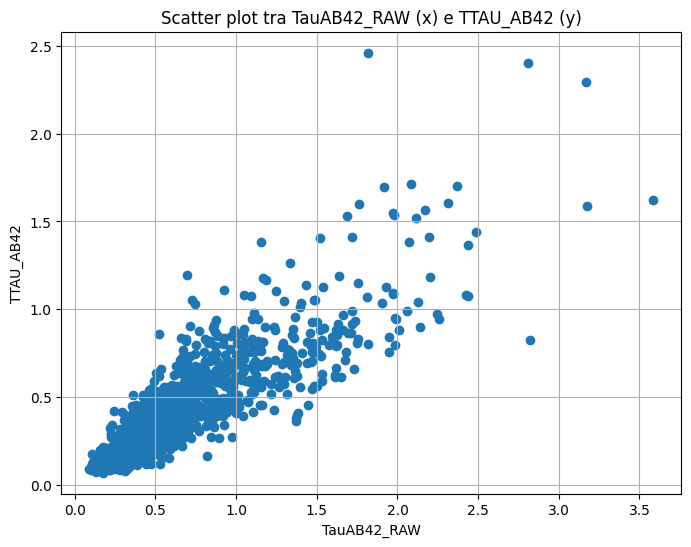

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("TauAB42_RAW")
plt.ylabel("TTAU_AB42")
plt.title("Scatter plot tra TauAB42_RAW (x) e TTAU_AB42 (y)")
plt.legend()
plt.grid(True)
plt.show()


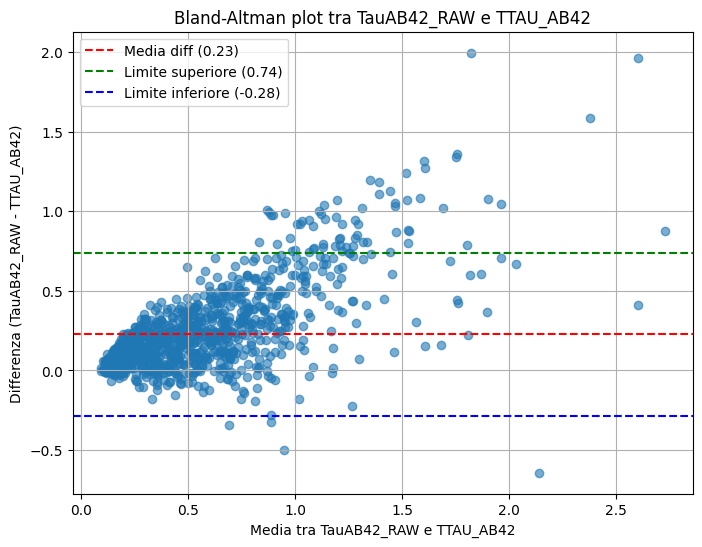

In [ ]:
import numpy as np

# Calcola le medie e le differenze tra le due variabili
means = (x + y) / 2
diffs = x - y

mean_diff = np.mean(diffs)
std_diff = np.std(diffs, ddof=1)  # ddof=1 per std campionaria

upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

plt.figure(figsize=(8,6))
plt.scatter(means, diffs, alpha=0.6)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Media diff ({mean_diff:.2f})')
plt.axhline(upper_limit, color='green', linestyle='--', label=f'Limite superiore ({upper_limit:.2f})')
plt.axhline(lower_limit, color='blue', linestyle='--', label=f'Limite inferiore ({lower_limit:.2f})')
plt.xlabel("Media tra TauAB42_RAW e TTAU_AB42")
plt.ylabel("Differenza (TauAB42_RAW - TTAU_AB42)")
plt.title("Bland-Altman plot tra TauAB42_RAW e TTAU_AB42")
plt.legend()
plt.grid(True)
plt.show()


#  Check metadata di tutti i file uno per uno

In [ ]:
i =9

In [21]:
file_name = 'UPENNBIOMKADNIDIAN2017_09Oct2025.csv' #files[0]
print(file_name, '----------')
metadata = client.get_metadata(object_name='raw/'+file_name)
display(metadata['metadata']['custom'])
i += 1

UPENNBIOMKADNIDIAN2017_09Oct2025.csv ----------


{'download_type': 'study_files',
 'file_code': 'UPENNBIOMK_ADNIDIAN_ES_2017',
 'level': 'raw',
 'population': ['1', 'GO', '2'],
 'source': 'ADNI'}

NameError: name 'i' is not defined

In [31]:
zip_files = client.download_file(object_name='raw/'+file_name,  
    extract_zip=True
)

In [4]:
file_code = 'ADNIMERGE'
search = client.query_files(
    query={
        'custom.level' : 'cleaned_01',
        'custom.file_code': file_code
    }
)

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)


In [15]:
file_name = list(zip_files.keys())[0]
dataset = zip_files[file_name]
zip_files

,RID,VISCODE,EXAMDATE,VERSION,IMAGE_UID,RUNDATE,STATUS,CBICA_ID,DATE,R702,...,R199,R200,R201,R202,R203,R204,R205,R206,R207,update_stamp
0,2,sc,2005-08-26,2016-03-21,I35475,2016-03-21,COMPLETE,011_S_0002_2005-08-26,2005-08-26,1784710,...,12577.70,7531.16,6862.94,8957.96,9767.36,3077.59,2563.72,1338.330,1044.690,2016-06-02 09:02:36.0
1,3,sc,2005-09-01,2016-03-21,I32237,2016-03-21,COMPLETE,011_S_0003_2005-09-01,2005-09-01,1785950,...,9596.26,6754.81,5647.18,8133.22,7992.18,3008.82,3520.32,1148.990,1203.530,2016-06-02 09:02:36.0
2,4,sc,2005-09-22,2016-03-21,I64631,2016-03-21,COMPLETE,022_S_0004_2005-09-22,2005-09-22,1619320,...,10444.50,7522.30,7652.39,8225.52,8943.81,2867.52,2141.69,1515.770,1755.200,2016-06-02 09:02:36.0
3,5,sc,2005-09-02,2016-03-21,I32246,2016-03-21,COMPLETE,011_S_0005_2005-09-02,2005-09-02,1655680,...,10243.40,5616.39,5902.29,8467.85,7683.51,2973.72,2405.68,1724.790,1643.910,2016-06-02 09:02:36.0
4,6,sc,2005-11-15,2016-03-21,I33025,2016-03-21,COMPLETE,100_S_0006_2005-11-15,2005-11-15,1528520,...,8364.14,5948.50,6253.38,5931.44,6659.54,2321.83,2245.08,1261.120,1250.460,2016-06-02 09:02:36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,1425,sc,2007-08-06,2016-03-21,I73357,2016-03-21,COMPLETE,041_S_1425_2007-08-06,2007-08-06,1360100,...,8223.08,6073.44,5872.55,6751.18,5906.35,3112.75,2164.66,1128.330,758.475,2016-06-02 09:02:38.0
836,1426,sc,2007-09-07,2016-03-21,I79102,2016-03-21,COMPLETE,137_S_1426_2007-09-07,2007-09-07,1612220,...,9022.20,5939.80,5302.83,6758.46,6978.18,1661.62,1788.38,944.368,1373.240,2016-06-02 09:02:38.0
837,1427,sc,2007-08-20,2016-03-21,I91126,2016-03-21,COMPLETE,127_S_1427_2007-08-20,2007-08-20,1552590,...,11428.10,6699.74,7530.97,9881.35,8473.67,3730.45,3510.70,1384.320,1608.320,2016-06-02 09:02:38.0
838,1430,sc,2007-09-07,2016-03-21,I79857,2016-03-21,COMPLETE,128_S_1430_2007-09-07,2007-09-07,1203100,...,7840.67,5337.89,5426.14,6072.02,6321.73,1960.17,1864.41,544.491,910.615,2016-06-02 09:02:38.0


In [ ]:

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True)

In [3]:
print(zip_files.keys())

dict_keys(['ADNIMERGE_06Jun2025.csv', 'MMSE_06Jun2025.csv', 'PTDEMOG_06Jun2025.csv', 'ADSP_PHC_BIOMARKER_06Jun2025.csv', 'BLCHANGE_06Jun2025.csv', 'DXSUM_06Jun2025.csv'])


In [14]:
file_name = 'ADNIMERGE_06Jun2025.csv'
df = zip_files[file_name]

NameError: name 'zip_files' is not defined

In [21]:
metadata = client.get_metadata(
            object_name = 'articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf'
        )
print(metadata['metadata'])

{'_id': '6838828ff99891d54bb44883', 'bucket_name': 'aind', 'content_type': 'application/pdf', 'created_at': '2025-05-29T15:51:43.525784', 'custom': {'author': 'Biel', 'keywords': ['ADNI', 'preclin', 'MCI', 'AD', 'imaging', 'Braak', 'staging', 'cogn', 'longit', 'predict'], 'year': '2021'}, 'filename': 'Biel_2021_ADNI_preclin_MCI_AD_imaging_Braak_staging_cogn_longit_predict.pdf', 'last_modified': '2025-05-29T15:51:43.443935', 'object_name': 'articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf', 'path': '/data/aind/articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf', 's3_url': 'http://131.175.204.159:9000/aind/articles/Biel%202021%20ADNI%20preclin%20MCI%20AD%20imaging%20Braak%20staging%20cogn%20longit%20predict.pdf?X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Credential=admin%2F20250529%2Fus-east-1%2Fs3%2Faws4_request&X-Amz-Date=20250529T155143Z&X-Amz-Expires=3600&X-Amz-SignedHeaders=host&X-Amz-Signature=9d7b5fec764c2b503c460b66

In [6]:
df

,PTID,RID,COHORT,VISCODE,EXAMDATE,AGE,GENDER,EDUCAT,ETHNICITY,RACE,...,FAQ,MOCA,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,ICV,DX,AGE_bl
0,011_S_0002,2,ADNI1,0,2005-09-08,74.3,1,16,0.0,5.0,...,0.0,NaN,118233.0,8336.0,4177.0,16559.0,27936.0,1984660.0,0,74.3
1,011_S_0003,3,ADNI1,0,2005-09-12,81.3,1,18,0.0,5.0,...,10.0,NaN,84599.0,5319.0,1791.0,15506.0,18422.0,1920690.0,3,81.3
2,011_S_0003,3,ADNI1,6,2006-03-13,81.8,1,18,0.0,5.0,...,12.0,NaN,88580.0,5446.0,2427.0,14400.0,16972.0,1906430.0,3,81.3
3,011_S_0003,3,ADNI1,12,2006-09-12,82.3,1,18,0.0,5.0,...,17.0,NaN,90099.0,5157.0,1596.0,14617.0,17330.0,1903820.0,3,81.3
4,011_S_0003,3,ADNI1,24,2007-09-12,83.3,1,18,0.0,5.0,...,14.0,NaN,97420.0,5139.0,1175.0,14033.0,16398.0,1903420.0,3,81.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11453,168_S_6180,6180,ADNI3,66,2023-07-25,92.0,1,16,0.0,5.0,...,7.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,1,86.8
11454,135_S_6446,6446,ADNI3,60,2023-07-12,66.5,1,12,0.0,5.0,...,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,1,61.5
11455,041_S_6731,6731,ADNI3,48,2023-07-31,70.9,0,20,0.0,5.0,...,7.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3,66.8
11456,035_S_6480,6480,ADNI3,60,2023-07-27,84.9,0,16,0.0,5.0,...,2.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,1,79.9
